<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
            padding: 60px 40px; border-radius: 16px; text-align: center;
            box-shadow: 0 8px 24px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">

  <div style="font-size: 48px; margin-bottom: 10px;">🏦🔍</div>

  <h1 style="color: #ffffff; font-size: 34px; margin: 0; letter-spacing: 1px;">
    Fraud Detection System
  </h1>

  <p style="color: #a0c4ff; font-size: 16px; margin-top: 8px; letter-spacing: 2px;
            text-transform: uppercase;">
    Mobile Money Transaction Analysis & ML Pipeline
  </p>

  <div style="width: 80px; height: 3px; background: #e94560; margin: 24px auto;"></div>

  <table style="margin: 0 auto; color: #dcdcdc; font-size: 14px;">
    <tr>
      <td style="padding: 6px 16px; text-align: right; font-weight: bold; color: #a0c4ff;">Author:</td>
      <td style="padding: 6px 16px; text-align: left;">Janvier Kwizera</td>
    </tr>
    <tr>
      <td style="padding: 6px 16px; text-align: right; font-weight: bold; color: #a0c4ff;">Role:</td>
      <td style="padding: 6px 16px; text-align: left;">Data Science, Analytics & AI</td>
    </tr>
    <tr>
      <td style="padding: 6px 16px; text-align: right; font-weight: bold; color: #a0c4ff;">Dataset:</td>
      <td style="padding: 6px 16px; text-align: left;">PaySim (Kaggle)</td>
    </tr>
    <tr>
      <td style="padding: 6px 16px; text-align: right; font-weight: bold; color: #a0c4ff;">Date:</td>
      <td style="padding: 6px 16px; text-align: left;">September 2026</td>
    </tr>
  </table>

  <div style="margin-top: 28px;">
    <span style="background: #0f3460; color: #a0c4ff; padding: 6px 14px; border-radius: 20px;
                 font-size: 12px; margin: 0 4px; border: 1px solid #a0c4ff;">Python</span>
    <span style="background: #0f3460; color: #a0c4ff; padding: 6px 14px; border-radius: 20px;
                 font-size: 12px; margin: 0 4px; border: 1px solid #a0c4ff;">RandomForest/XGBoost</span>
    <span style="background: #0f3460; color: #a0c4ff; padding: 6px 14px; border-radius: 20px;
                 font-size: 12px; margin: 0 4px; border: 1px solid #a0c4ff;">Scikit-learn</span>
    <span style="background: #0f3460; color: #a0c4ff; padding: 6px 14px; border-radius: 20px;
                 font-size: 12px; margin: 0 4px; border: 1px solid #a0c4ff;">Flask</span>
  </div>

</div>

***LOAD DATA.***

In [1]:
import pandas as pd
import numpy as np

In [2]:
Data = pd.read_csv("Fraud.csv")
Data

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [3]:
Data.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [48]:
Data = "Fraud.csv"
df = pd.read_csv(Data)

In [5]:
print("Initial shape:", df.shape)
print(df.dtypes)

Initial shape: (6362620, 11)
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [6]:
# ------------------------------------------------------------------
# 2. BASIC INSPECTION
# ------------------------------------------------------------------
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nUnique transaction types:", df['type'].unique())
print("\nisFraud value counts:\n", df['isFraud'].value_counts())


Missing values per column:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0

Unique transaction types: <ArrowStringArray>
['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']
Length: 5, dtype: str

isFraud value counts:
 isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [7]:
# ------------------------------------------------------------------
# 3. DROP EXACT DUPLICATES
# ------------------------------------------------------------------
before = df.shape[0]
df = df.drop_duplicates()
print(f"\nDropped {before - df.shape[0]} duplicate rows")

# ------------------------------------------------------------------
# 4. HANDLE MISSING VALUES
# ------------------------------------------------------------------
# PaySim-style data is usually complete, but handle gracefully if not.
numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
                 'oldbalanceDest', 'newbalanceDest']
categorical_cols = ['type', 'nameOrig', 'nameDest']

# Numeric: fill with median (robust to outliers), or drop rows if critical
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Categorical: drop rows missing type/nameOrig/nameDest (rare, but critical ids)
df = df.dropna(subset=[c for c in categorical_cols if c in df.columns])

# ------------------------------------------------------------------
# 5. FIX DATA TYPES
# ------------------------------------------------------------------
df['step'] = df['step'].astype(int)
df['type'] = df['type'].astype('category')
df['nameOrig'] = df['nameOrig'].astype(str)
df['nameDest'] = df['nameDest'].astype(str)
df['isFraud'] = df['isFraud'].astype(int)
df['isFlaggedFraud'] = df['isFlaggedFraud'].astype(int)

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ------------------------------------------------------------------
# 6. REMOVE INVALID / IMPOSSIBLE VALUES
# ------------------------------------------------------------------
# Negative amounts or balances are not physically meaningful
before = df.shape[0]
df = df[(df['amount'] >= 0) &
        (df['oldbalanceOrg'] >= 0) &
        (df['newbalanceOrig'] >= 0) &
        (df['oldbalanceDest'] >= 0) &
        (df['newbalanceDest'] >= 0)]
print(f"\nDropped {before - df.shape[0]} rows with negative amount/balance values")

# ------------------------------------------------------------------
# 7. FEATURE ENGINEERING (commonly useful for fraud detection)
# ------------------------------------------------------------------
# Balance discrepancy features — mismatches here are strong fraud signals
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# Flags for zero-balance accounts (common in PaySim fraud patterns)
df['origBalanceZero'] = ((df['oldbalanceOrg'] == 0) & (df['newbalanceOrig'] == 0)).astype(int)
df['destBalanceZero'] = ((df['oldbalanceDest'] == 0) & (df['newbalanceDest'] == 0)).astype(int)

# Whether origin/destination account is a merchant (PaySim convention: "M" prefix)
df['origIsMerchant'] = df['nameOrig'].str.startswith('M').astype(int)
df['destIsMerchant'] = df['nameDest'].str.startswith('M').astype(int)

# ------------------------------------------------------------------
# 8. OUTLIER CHECK (informational — do NOT blindly drop in fraud data,
#    since large/rare amounts are often exactly what signals fraud)
# ------------------------------------------------------------------
q1, q3 = df['amount'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
print(f"\nAmount outlier threshold (upper): {upper_bound:,.2f}")
print(f"Rows above threshold: {(df['amount'] > upper_bound).sum()} "
      f"(keep these — flag rather than remove, since fraud correlates with large amounts)")

# ------------------------------------------------------------------
# 9. FINAL CHECKS
# ------------------------------------------------------------------
print("\nFinal shape:", df.shape)
print("\nFinal dtypes:\n", df.dtypes)
print("\nClass balance (isFraud):\n", df['isFraud'].value_counts(normalize=True))

# ------------------------------------------------------------------
# 10. SAVE CLEANED DATA
# ------------------------------------------------------------------
OUTPUT_PATH = "cleaned_fraud_data.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"\nCleaned data saved to {OUTPUT_PATH}")


Dropped 0 duplicate rows

Dropped 0 rows with negative amount/balance values

Amount outlier threshold (upper): 501,719.34
Rows above threshold: 338078 (keep these — flag rather than remove, since fraud correlates with large amounts)

Final shape: (6362620, 17)

Final dtypes:
 step                   int64
type                category
amount               float64
nameOrig                 str
oldbalanceOrg        float64
newbalanceOrig       float64
nameDest                 str
oldbalanceDest       float64
newbalanceDest       float64
isFraud                int64
isFlaggedFraud         int64
errorBalanceOrig     float64
errorBalanceDest     float64
origBalanceZero        int64
destBalanceZero        int64
origIsMerchant         int64
destIsMerchant         int64
dtype: object

Class balance (isFraud):
 isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

Cleaned data saved to cleaned_fraud_data.csv


***Exploratory Data Analysis (EDA).***

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ------------------------------------------------------------------
# 1. LOAD CLEANED DATA
# ------------------------------------------------------------------
df = pd.read_csv("cleaned_fraud_data.csv")
print("Shape:", df.shape)

Shape: (6362620, 17)


In [9]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest,origBalanceZero,destBalanceZero,origIsMerchant,destIsMerchant
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,0.0,9.839640e+03,0,1,0,1
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,0.0,1.864280e+03,0,1,0,1
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,0.0,1.810000e+02,0,1,0,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,0.0,2.136300e+04,0,0,0,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,0.0,1.166814e+04,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,0.0,0.000000e+00,0,0,0,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,0.0,6.311409e+06,0,1,0,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,0.0,1.000000e-02,0,0,0,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,0.0,8.500025e+05,0,1,0,0



Fraud class distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


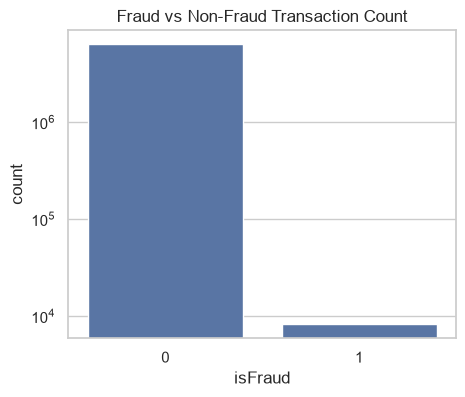

In [10]:
# ------------------------------------------------------------------
# 2. CLASS DISTRIBUTION (fraud is usually extremely imbalanced)
# ------------------------------------------------------------------
print("\nFraud class distribution:")
print(df['isFraud'].value_counts())
print(df['isFraud'].value_counts(normalize=True) * 100)

plt.figure(figsize=(5, 4))
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transaction Count")
plt.yscale('log')  # log scale since fraud is rare
plt.show()


Fraud rate by transaction type:
           total_transactions  fraud_count  fraud_rate
type                                                 
CASH_IN              1399284            0    0.000000
CASH_OUT             2237500         4116    0.001840
DEBIT                  41432            0    0.000000
PAYMENT              2151495            0    0.000000
TRANSFER              532909         4097    0.007688


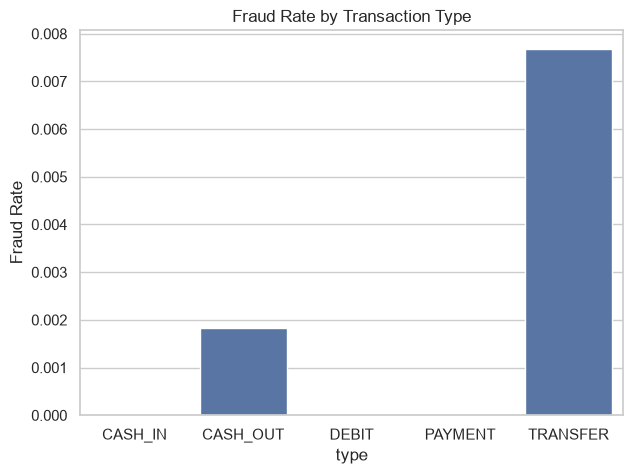

In [11]:
# ------------------------------------------------------------------
# 3. FRAUD RATE BY TRANSACTION TYPE
# ------------------------------------------------------------------
fraud_by_type = df.groupby('type')['isFraud'].agg(['count', 'sum', 'mean'])
fraud_by_type.columns = ['total_transactions', 'fraud_count', 'fraud_rate']
print("\nFraud rate by transaction type:\n", fraud_by_type)

plt.figure(figsize=(7, 5))
sns.barplot(x=fraud_by_type.index, y=fraud_by_type['fraud_rate'])
plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Rate")
plt.show()

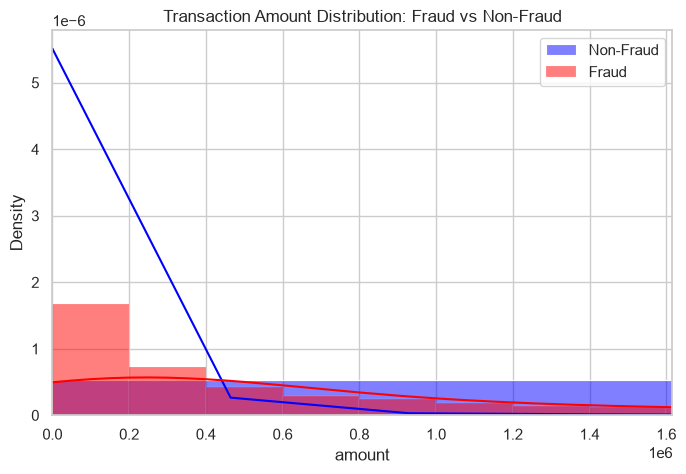


Amount stats — Non-Fraud:
 count    6.354407e+06
mean     1.781970e+05
std      5.962370e+05
min      1.000000e-02
25%      1.336840e+04
50%      7.468472e+04
75%      2.083648e+05
max      9.244552e+07
Name: amount, dtype: float64

Amount stats — Fraud:
 count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64


In [12]:
# ------------------------------------------------------------------
# 4. AMOUNT DISTRIBUTION: FRAUD VS NON-FRAUD
# ------------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.histplot(df[df['isFraud'] == 0]['amount'], bins=50, color='blue',
             label='Non-Fraud', stat='density', kde=True, alpha=0.5)
sns.histplot(df[df['isFraud'] == 1]['amount'], bins=50, color='red',
             label='Fraud', stat='density', kde=True, alpha=0.5)
plt.xlim(0, df['amount'].quantile(0.99))  # trim extreme tail for readability
plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")
plt.legend()
plt.show()

print("\nAmount stats — Non-Fraud:\n", df[df['isFraud'] == 0]['amount'].describe())
print("\nAmount stats — Fraud:\n", df[df['isFraud'] == 1]['amount'].describe())



errorBalanceOrig by fraud status:
              count           mean            std           min       25%  \
isFraud                                                                    
0        6354407.0  201338.558109  606928.890826 -1.000000e-02  3034.305   
1           8213.0   10692.325265  265146.131130 -7.450581e-09     0.000   

              50%        75%          max  
isFraud                                    
0        69049.31  249953.43  92445516.64  
1            0.00       0.00  10000000.00  

errorBalanceDest by fraud status:
              count           mean           std          min  25%      50%  \
isFraud                                                                      
0        6354407.0   54692.231734  4.360026e+05 -75885725.63  0.0  3500.68   
1           8213.0  732509.301069  1.867748e+06  -8875516.29  0.0  2231.46   

                75%          max  
isFraud                           
0         29259.805  13191233.98  
1        442722.010  10000000

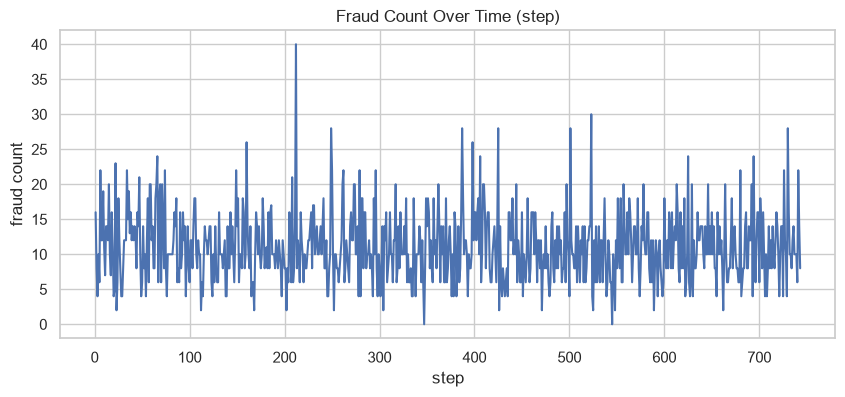

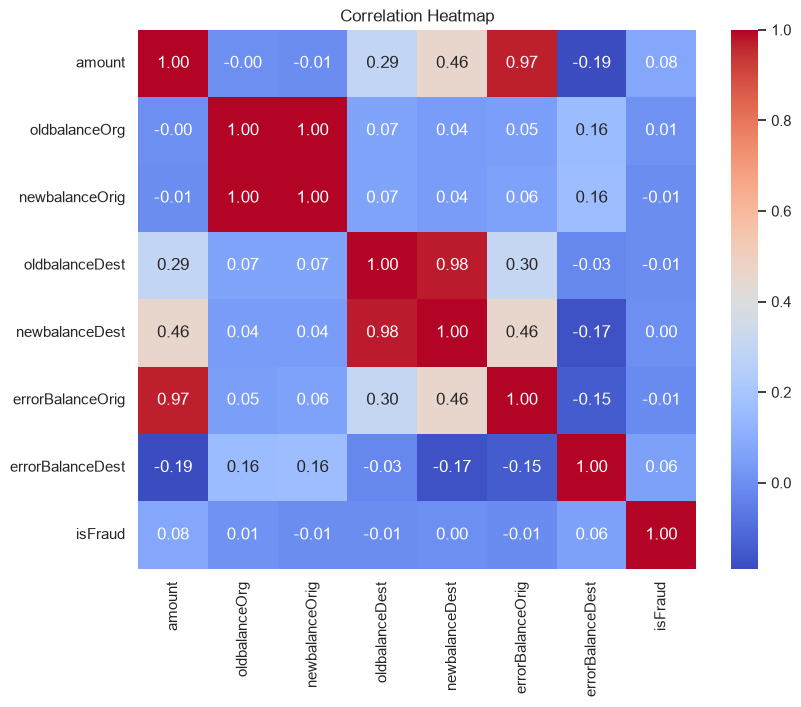

In [13]:
# ------------------------------------------------------------------
# 5. BALANCE ERROR FEATURES (from cleaning step) VS FRAUD
# ------------------------------------------------------------------
print("\nerrorBalanceOrig by fraud status:\n",
      df.groupby('isFraud')['errorBalanceOrig'].describe())
print("\nerrorBalanceDest by fraud status:\n",
      df.groupby('isFraud')['errorBalanceDest'].describe())

# ------------------------------------------------------------------
# 6. ZERO-BALANCE PATTERNS VS FRAUD
# ------------------------------------------------------------------
zero_balance_fraud = df.groupby('origBalanceZero')['isFraud'].mean()
print("\nFraud rate when origin balance is zero before & after:\n", zero_balance_fraud)

dest_zero_fraud = df.groupby('destBalanceZero')['isFraud'].mean()
print("\nFraud rate when destination balance is zero before & after:\n", dest_zero_fraud)

# ------------------------------------------------------------------
# 7. isFlaggedFraud VS ACTUAL isFraud (check system's existing flag)
# ------------------------------------------------------------------
print("\nCross-tab: isFlaggedFraud vs isFraud\n",
      pd.crosstab(df['isFlaggedFraud'], df['isFraud']))
# Useful to see how well the existing rule-based flag performs
# (in PaySim, isFlaggedFraud catches almost none of the real fraud)

# ------------------------------------------------------------------
# 8. FRAUD OVER TIME (step = hour-like time unit)
# ------------------------------------------------------------------
fraud_over_time = df.groupby('step')['isFraud'].sum()
plt.figure(figsize=(10, 4))
fraud_over_time.plot()
plt.title("Fraud Count Over Time (step)")
plt.xlabel("step")
plt.ylabel("fraud count")
plt.show()

# ------------------------------------------------------------------
# 9. CORRELATION HEATMAP (numeric features only)
# ------------------------------------------------------------------
numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
                 'oldbalanceDest', 'newbalanceDest',
                 'errorBalanceOrig', 'errorBalanceDest', 'isFraud']
plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

***Feature Engineering.***


In [14]:
"""
Feature Engineering, Encoding & Train/Test Split

"""

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------------
# 1. LOAD CLEANED DATA
# ------------------------------------------------------------------
df = pd.read_csv("cleaned_fraud_data.csv")
print("Loaded shape:", df.shape)

Loaded shape: (6362620, 17)


In [15]:
# ------------------------------------------------------------------
# 2. DROP HIGH-CARDINALITY ID COLUMNS
# ------------------------------------------------------------------
# nameOrig / nameDest are near-unique per row (millions of distinct values).
# They carry no generalizable signal for a model and would blow up
# dimensionality if one-hot encoded. We already extracted the useful
# signal from them (origIsMerchant / destIsMerchant) during cleaning.
df = df.drop(columns=['nameOrig', 'nameDest'])

# ------------------------------------------------------------------
# 3. ONE-HOT ENCODE 'type'
# ------------------------------------------------------------------
# type has few categories (CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER)
# so one-hot encoding is appropriate (no ordinal relationship between them).
df = pd.get_dummies(df, columns=['type'], prefix='type', drop_first=True)
# drop_first=True avoids the "dummy variable trap" (multicollinearity)
# for linear models; tree-based models are unaffected either way.

print("\nColumns after encoding:\n", df.columns.tolist())


Columns after encoding:
 ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'errorBalanceOrig', 'errorBalanceDest', 'origBalanceZero', 'destBalanceZero', 'origIsMerchant', 'destIsMerchant', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [16]:
# ------------------------------------------------------------------
# 4. DEFINE FEATURES (X) AND TARGET (y)
# ------------------------------------------------------------------
# isFlaggedFraud is the system's OWN rule-based flag, not a real predictive
# feature — including it would leak information/bias results. Drop it here
# and analyze it separately (as done in the EDA cross-tab) if needed.
X = df.drop(columns=['isFraud', 'isFlaggedFraud'])
y = df['isFraud']

print("\nFeature columns:\n", X.columns.tolist())
print("\nTarget distribution:\n", y.value_counts(normalize=True))


Feature columns:
 ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'origBalanceZero', 'destBalanceZero', 'origIsMerchant', 'destIsMerchant', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Target distribution:
 isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [17]:
# ------------------------------------------------------------------
# 5. STRATIFIED TRAIN/TEST SPLIT
# ------------------------------------------------------------------
# stratify=y ensures both train and test sets keep the same (tiny)
# fraud ratio -- critical for imbalanced classification problems.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain fraud ratio:\n", y_train.value_counts(normalize=True))
print("\nTest fraud ratio:\n", y_test.value_counts(normalize=True))


Train shape: (5090096, 16)  Test shape: (1272524, 16)

Train fraud ratio:
 isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

Test fraud ratio:
 isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [18]:
# ------------------------------------------------------------------
# 6. SAVE SPLITS FOR NEXT STEP (MODELING)
# ------------------------------------------------------------------
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("\nSaved: X_train.csv, X_test.csv, y_train.csv, y_test.csv")
print("Ready for class-imbalance handling + model training.")


Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv
Ready for class-imbalance handling + model training.


***Class Imbalance Handling + Baseline Model Training***.


In [19]:
"""
Class Imbalance Handling + Baseline Model Training
Run this AFTER feature_engineering_split.py
"""
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_curve, average_precision_score,
                              roc_auc_score)
from imblearn.over_sampling import SMOTE

# ------------------------------------------------------------------
# 1. LOAD TRAIN/TEST SPLITS
# ------------------------------------------------------------------
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

print("Train shape:", X_train.shape)
print("Original train fraud ratio:\n", y_train.value_counts(normalize=True))

Train shape: (5090096, 16)
Original train fraud ratio:
 isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [20]:
# ------------------------------------------------------------------
# 2. HANDLE CLASS IMBALANCE
# ------------------------------------------------------------------
# IMPORTANT: Only resample the TRAINING set. The test set must stay
# untouched and reflect the real-world fraud ratio, otherwise your
# evaluation metrics will be misleadingly optimistic.

# Option A: SMOTE (Synthetic Minority Over-sampling) — creates synthetic
# fraud examples rather than just duplicating existing ones.
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE - train fraud ratio:\n",
      y_train_smote.value_counts(normalize=True))


After SMOTE - train fraud ratio:
 isFraud
0    0.5
1    0.5
Name: proportion, dtype: float64


In [21]:
# Option B: class_weight='balanced' — no resampling, model penalizes
# misclassifying the minority class more heavily. Often faster and
# avoids inflating dataset size. Used below as an alternative to compare.

# ------------------------------------------------------------------
# 3. BASELINE MODEL 1 — Logistic Regression (with class_weight)
# ------------------------------------------------------------------
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("\n=== Logistic Regression (class_weight balanced) ===")
print(classification_report(y_test, y_pred_lr, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print("PR-AUC (average precision):", average_precision_score(y_test, y_proba_lr))

# ------------------------------------------------------------------
# 4. BASELINE MODEL 2 — Random Forest (trained on SMOTE-balanced data)
# ------------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== Random Forest (trained on SMOTE-balanced data) ===")
print(classification_report(y_test, y_pred_rf, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("PR-AUC (average precision):", average_precision_score(y_test, y_proba_rf))

# ------------------------------------------------------------------
# 5. WHY PR-AUC MATTERS MORE THAN ROC-AUC HERE
# ------------------------------------------------------------------
# With ~99%+ non-fraud cases, ROC-AUC can look excellent even when
# the model misses most fraud, because it's diluted by the huge
# number of true negatives. PR-AUC focuses on precision/recall
# trade-offs for the minority (fraud) class specifically.

# ------------------------------------------------------------------
# 6. SAVE MODELS FOR NEXT STEP (feature importance + tuning)
# ------------------------------------------------------------------
import joblib
joblib.dump(log_reg, "logistic_regression_model.pkl")
joblib.dump(rf, "random_forest_model.pkl")

print("\nModels saved: logistic_regression_model.pkl, random_forest_model.pkl")
print("Compare the two reports above — Random Forest typically captures")
print("more fraud (higher recall) due to non-linear pattern detection.")


=== Logistic Regression (class_weight balanced) ===
              precision    recall  f1-score   support

           0     0.9999    0.9566    0.9778   1270881
           1     0.0273    0.9428    0.0531      1643

    accuracy                         0.9566   1272524
   macro avg     0.5136    0.9497    0.5154   1272524
weighted avg     0.9987    0.9566    0.9766   1272524

Confusion matrix:
 [[1215738   55143]
 [     94    1549]]
ROC-AUC: 0.9894151343150546
PR-AUC (average precision): 0.5798415985737726

=== Random Forest (trained on SMOTE-balanced data) ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9687    0.9982    0.9832      1643

    accuracy                         1.0000   1272524
   macro avg     0.9843    0.9991    0.9916   1272524
weighted avg     1.0000    1.0000    1.0000   1272524

Confusion matrix:
 [[1270828      53]
 [      3    1640]]
ROC-AUC: 0.9997402547561953
PR-AUC (average pr

***Supervised (XGBoost/LightGBM) + Unsupervised Anomaly Detection (Isolation Forest) + 
Graph/Network Features.***

In [22]:
"""
Extended Fraud Modeling: Supervised (XGBoost/LightGBM) +
Unsupervised Anomaly Detection (Isolation Forest) +
Graph/Network Features

Run this AFTER feature_engineering_split.py
Note: nameOrig/nameDest were dropped during feature engineering for the
plain ML models, but the graph model needs them — so we reload the
cleaned data separately for that part.
"""

import pandas as pd
import numpy as np
from sklearn.metrics import (classification_report, confusion_matrix,
                              average_precision_score, roc_auc_score)
from sklearn.ensemble import IsolationForest
import joblib

***PART 1: SUPERVISED MODELS — XGBoost & LightGBM (Known Patterns).***

In [23]:
#!pip install xgboost lightgbm networkx

In [24]:
#pip install xgboost lightgbm networkx

In [25]:
# ==================================================================
# PART 1: SUPERVISED MODELS — XGBoost & LightGBM (Known Patterns)
# ==================================================================
import xgboost as xgb
import lightgbm as lgb

In [26]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

# scale_pos_weight handles class imbalance directly (alternative to SMOTE)
# = ratio of negative to positive class
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (imbalance ratio): {scale_pos_weight:.2f}")

scale_pos_weight (imbalance ratio): 773.75


***XGBoost.***

In [27]:
# ---- XGBoost ----
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',   # optimize for precision-recall AUC, not accuracy
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("PR-AUC:", average_precision_score(y_test, y_proba_xgb))


=== XGBoost ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9957    0.9976    0.9967      1643

    accuracy                         1.0000   1272524
   macro avg     0.9979    0.9988    0.9983   1272524
weighted avg     1.0000    1.0000    1.0000   1272524

Confusion matrix:
 [[1270874       7]
 [      4    1639]]
ROC-AUC: 0.9994742841090645
PR-AUC: 0.9983298813979916


***LightGBM.***

In [28]:
# ---- LightGBM ----
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(X_train, y_train)

y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_pred_lgb = lgb_model.predict(X_test)

print("\n=== LightGBM ===")
print(classification_report(y_test, y_pred_lgb, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lgb))
print("PR-AUC:", average_precision_score(y_test, y_proba_lgb))

# Feature importance — which signals each model actually relies on
print("\nXGBoost feature importance:")
print(pd.Series(xgb_model.feature_importances_, index=X_train.columns)
      .sort_values(ascending=False))

print("\nLightGBM feature importance:")
print(pd.Series(lgb_model.feature_importances_, index=X_train.columns)
      .sort_values(ascending=False))

joblib.dump(xgb_model, "xgboost_model.pkl")
joblib.dump(lgb_model, "lightgbm_model.pkl")


=== LightGBM ===
              precision    recall  f1-score   support

           0     0.9999    0.9296    0.9634   1270881
           1     0.0163    0.9038    0.0321      1643

    accuracy                         0.9295   1272524
   macro avg     0.5081    0.9167    0.4977   1272524
weighted avg     0.9986    0.9295    0.9622   1272524

Confusion matrix:
 [[1181352   89529]
 [    158    1485]]
ROC-AUC: 0.916693642815771
PR-AUC: 0.014871280241368955

XGBoost feature importance:
newbalanceOrig      0.544450
errorBalanceOrig    0.395560
amount              0.019977
destBalanceZero     0.018967
origBalanceZero     0.009832
errorBalanceDest    0.003034
type_CASH_OUT       0.002164
oldbalanceDest      0.001618
type_TRANSFER       0.001579
step                0.001145
oldbalanceOrg       0.000841
newbalanceDest      0.000522
destIsMerchant      0.000259
type_DEBIT          0.000055
origIsMerchant      0.000000
type_PAYMENT        0.000000
dtype: float32

LightGBM feature importance:
ste

['lightgbm_model.pkl']

***PART 2: UNSUPERVISED ANOMALY DETECTION — Isolation Forest.***


In [29]:
# ==================================================================
# PART 2: UNSUPERVISED ANOMALY DETECTION — Isolation Forest
# (Novel Patterns — doesn't use isFraud labels to fit)
# ==================================================================
# contamination = expected proportion of anomalies; set close to the
# real fraud rate in your data as a starting estimate.
fraud_rate = y_train.mean()
print(f"\nUsing contamination={fraud_rate:.5f} (approx. real fraud rate)")

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=fraud_rate,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train)  # unsupervised — no y_train used here

# predict: -1 = anomaly (flag as potential fraud), 1 = normal
anomaly_pred = iso_forest.predict(X_test)
anomaly_pred_binary = np.where(anomaly_pred == -1, 1, 0)  # convert to 0/1

print("\n=== Isolation Forest (unsupervised anomaly detection) ===")
print(classification_report(y_test, anomaly_pred_binary, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, anomaly_pred_binary))
print("Note: compare recall here vs XGBoost/LightGBM above — Isolation")
print("Forest exists to catch NOVEL fraud patterns not in historical")
print("labels, so a lower precision here is expected and acceptable")
print("if it's flagging genuinely different transaction behavior.")

joblib.dump(iso_forest, "isolation_forest_model.pkl")


Using contamination=0.00129 (approx. real fraud rate)

=== Isolation Forest (unsupervised anomaly detection) ===
              precision    recall  f1-score   support

           0     0.9987    0.9988    0.9987   1270881
           1     0.0144    0.0140    0.0142      1643

    accuracy                         0.9975   1272524
   macro avg     0.5066    0.5064    0.5065   1272524
weighted avg     0.9975    0.9975    0.9975   1272524

Confusion matrix:
 [[1269307    1574]
 [   1620      23]]
Note: compare recall here vs XGBoost/LightGBM above — Isolation
Forest exists to catch NOVEL fraud patterns not in historical
labels, so a lower precision here is expected and acceptable
if it's flagging genuinely different transaction behavior.


['isolation_forest_model.pkl']

***PART 3: GRAPH / NETWORK FEATURES (Coordinated fraud / rings).***


In [30]:
# ==================================================================
# PART 3: GRAPH / NETWORK FEATURES (Coordinated fraud / rings)
# ==================================================================
# Reload cleaned data WITH nameOrig/nameDest to build the transaction graph.
df_graph = pd.read_csv("cleaned_fraud_data.csv")

import networkx as nx

# Build a directed graph: edge from nameOrig -> nameDest for every transaction
G = nx.from_pandas_edgelist(
    df_graph, source='nameOrig', target='nameDest',
    edge_attr='amount', create_using=nx.DiGraph()
)

print(f"\nGraph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ---- Node-level network features that flag coordinated fraud ----
# in_degree: how many distinct accounts sent money TO this account
#            (mule accounts often receive from many different senders)
# out_degree: how many distinct accounts this account sent money TO
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

df_graph['dest_in_degree'] = df_graph['nameDest'].map(in_degree)
df_graph['orig_out_degree'] = df_graph['nameOrig'].map(out_degree)

# Fraud rate vs receiving-account "fan-in" (many senders -> one receiver
# is a classic mule/money-laundering signature)
print("\nFraud rate by destination in-degree (binned):")
df_graph['dest_in_degree_bin'] = pd.cut(
    df_graph['dest_in_degree'], bins=[0, 1, 2, 5, 10, np.inf],
    labels=['1', '2', '3-5', '6-10', '10+']
)
print(df_graph.groupby('dest_in_degree_bin', observed=True)['isFraud'].agg(
    ['count', 'mean']))

# Save the graph-enriched dataset for use back in supervised models
df_graph.to_csv("cleaned_fraud_data_with_graph_features.csv", index=False)
print("\nSaved cleaned_fraud_data_with_graph_features.csv")
print("Consider re-running feature_engineering_split.py + model_training.py")
print("on this file to let XGBoost/LightGBM use dest_in_degree /")
print("orig_out_degree as additional predictive features.")


Graph built: 9073900 nodes, 6362620 edges

Fraud rate by destination in-degree (binned):
                      count      mean
dest_in_degree_bin                   
1                   2262704  0.001181
2                    154108  0.004886
3-5                  536432  0.002418
6-10                 869418  0.001446
10+                 2539958  0.000879

Saved cleaned_fraud_data_with_graph_features.csv
Consider re-running feature_engineering_split.py + model_training.py
on this file to let XGBoost/LightGBM use dest_in_degree /
orig_out_degree as additional predictive features.


***Graph Features Into the Pipeline.***

In [31]:
"""
Step 1: Wire Graph Features Into the Pipeline
Re-encode + re-split using the graph-enriched dataset, retrain
XGBoost/LightGBM, and compare PR-AUC against the original baseline
(without graph features).

Run this AFTER extended_modeling_all_approaches.py has produced
cleaned_fraud_data_with_graph_features.csv
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              average_precision_score, roc_auc_score)
import xgboost as xgb
import lightgbm as lgb
import joblib

# ------------------------------------------------------------------
# 1. LOAD GRAPH-ENRICHED DATA
# ------------------------------------------------------------------
df = pd.read_csv("cleaned_fraud_data_with_graph_features.csv")
print("Loaded shape:", df.shape)

# Fill any NaN degrees (shouldn't happen, but safe) with 0
df['dest_in_degree'] = df['dest_in_degree'].fillna(0)
df['orig_out_degree'] = df['orig_out_degree'].fillna(0)

Loaded shape: (6362620, 20)


In [32]:
# ------------------------------------------------------------------
# 2. DROP ID / HELPER COLUMNS NOT USED AS MODEL FEATURES
# ------------------------------------------------------------------
# nameOrig/nameDest: high-cardinality IDs, no generalizable signal
# dest_in_degree_bin: was only for EDA readability, the raw numeric
#                      dest_in_degree column is what the model uses
drop_cols = ['nameOrig', 'nameDest']
if 'dest_in_degree_bin' in df.columns:
    drop_cols.append('dest_in_degree_bin')
df = df.drop(columns=drop_cols)

# ------------------------------------------------------------------
# 3. ONE-HOT ENCODE 'type'
# ------------------------------------------------------------------
df = pd.get_dummies(df, columns=['type'], prefix='type', drop_first=True)

# ------------------------------------------------------------------
# 4. DEFINE FEATURES (X) AND TARGET (y)
# ------------------------------------------------------------------
X = df.drop(columns=['isFraud', 'isFlaggedFraud'])
y = df['isFraud']

print("\nFeature columns (with graph features):\n", X.columns.tolist())


Feature columns (with graph features):
 ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'origBalanceZero', 'destBalanceZero', 'origIsMerchant', 'destIsMerchant', 'dest_in_degree', 'orig_out_degree', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


***RETRAIN XGBOOST/LIGHTGBM WITH GRAPH FEATURES.***


In [33]:
# ------------------------------------------------------------------
# 5. STRATIFIED TRAIN/TEST SPLIT
# ------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# ------------------------------------------------------------------
# 6. RETRAIN XGBOOST WITH GRAPH FEATURES
# ------------------------------------------------------------------
xgb_graph = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='aucpr',
    random_state=42, n_jobs=-1
)
xgb_graph.fit(X_train, y_train)
proba_xgb_graph = xgb_graph.predict_proba(X_test)[:, 1]
pred_xgb_graph = xgb_graph.predict(X_test)

print("\n=== XGBoost WITH graph features ===")
print(classification_report(y_test, pred_xgb_graph, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_xgb_graph))
pr_auc_xgb_graph = average_precision_score(y_test, proba_xgb_graph)
roc_auc_xgb_graph = roc_auc_score(y_test, proba_xgb_graph)
print("ROC-AUC:", roc_auc_xgb_graph)
print("PR-AUC:", pr_auc_xgb_graph)


=== XGBoost WITH graph features ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9976    0.9976    0.9976      1643

    accuracy                         1.0000   1272524
   macro avg     0.9988    0.9988    0.9988   1272524
weighted avg     1.0000    1.0000    1.0000   1272524

Confusion matrix:
 [[1270877       4]
 [      4    1639]]
ROC-AUC: 0.9995049729193686
PR-AUC: 0.9981072643815024


In [34]:
# ------------------------------------------------------------------
# 7. RETRAIN LIGHTGBM WITH GRAPH FEATURES
# ------------------------------------------------------------------
lgb_graph = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42,
    n_jobs=-1, verbose=-1
)
lgb_graph.fit(X_train, y_train)
proba_lgb_graph = lgb_graph.predict_proba(X_test)[:, 1]
pred_lgb_graph = lgb_graph.predict(X_test)

print("\n=== LightGBM WITH graph features ===")
print(classification_report(y_test, pred_lgb_graph, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_lgb_graph))
pr_auc_lgb_graph = average_precision_score(y_test, proba_lgb_graph)
roc_auc_lgb_graph = roc_auc_score(y_test, proba_lgb_graph)
print("ROC-AUC:", roc_auc_lgb_graph)
print("PR-AUC:", pr_auc_lgb_graph)


=== LightGBM WITH graph features ===
              precision    recall  f1-score   support

           0     0.9997    0.7730    0.8718   1270881
           1     0.0045    0.8010    0.0090      1643

    accuracy                         0.7730   1272524
   macro avg     0.5021    0.7870    0.4404   1272524
weighted avg     0.9984    0.7730    0.8707   1272524

Confusion matrix:
 [[982376 288505]
 [   327   1316]]
ROC-AUC: 0.7869802246244004
PR-AUC: 0.00389397851907624


In [35]:
# ------------------------------------------------------------------
# 8. FEATURE IMPORTANCE — check where graph features rank
# ------------------------------------------------------------------
print("\nXGBoost feature importance (with graph features):")
print(pd.Series(xgb_graph.feature_importances_, index=X_train.columns)
      .sort_values(ascending=False))

print("\nLightGBM feature importance (with graph features):")
print(pd.Series(lgb_graph.feature_importances_, index=X_train.columns)
      .sort_values(ascending=False))


XGBoost feature importance (with graph features):
newbalanceOrig      0.546044
errorBalanceOrig    0.390005
destBalanceZero     0.020921
amount              0.020577
origBalanceZero     0.010847
errorBalanceDest    0.003022
type_CASH_OUT       0.002002
oldbalanceDest      0.001535
type_TRANSFER       0.001321
step                0.001318
oldbalanceOrg       0.000888
dest_in_degree      0.000702
newbalanceDest      0.000503
destIsMerchant      0.000276
type_DEBIT          0.000039
origIsMerchant      0.000000
orig_out_degree     0.000000
type_PAYMENT        0.000000
dtype: float32

LightGBM feature importance (with graph features):
step                333
amount              314
errorBalanceDest    278
oldbalanceOrg       258
errorBalanceOrig    217
oldbalanceDest      198
newbalanceDest      177
newbalanceOrig      159
dest_in_degree      158
type_CASH_OUT        26
origBalanceZero      24
type_TRANSFER        17
type_DEBIT           11
destIsMerchant        7
destBalanceZero       6


***COMPARE AGAINST BASELINE (without graph features).***

In [36]:
# ------------------------------------------------------------------
# 9. COMPARE AGAINST BASELINE (without graph features)
# ------------------------------------------------------------------
# Load the previously saved baseline models (trained WITHOUT graph features)
# to compare on the same-shaped metric, if available.
try:
    xgb_baseline = joblib.load("xgboost_model.pkl")
    X_test_baseline = pd.read_csv("X_test.csv")
    y_test_baseline = pd.read_csv("y_test.csv").squeeze()
    proba_xgb_baseline = xgb_baseline.predict_proba(X_test_baseline)[:, 1]
    pr_auc_xgb_baseline = average_precision_score(y_test_baseline, proba_xgb_baseline)

    print("\n=== COMPARISON: XGBoost PR-AUC ===")
    print(f"Without graph features: {pr_auc_xgb_baseline:.4f}")
    print(f"With graph features:    {pr_auc_xgb_graph:.4f}")
    diff = pr_auc_xgb_graph - pr_auc_xgb_baseline
    print(f"Difference: {diff:+.4f} "
          f"({'improvement' if diff > 0 else 'no improvement / worse'})")
except FileNotFoundError:
    print("\nBaseline model file not found — run extended_modeling_all_approaches.py "
          "first to generate xgboost_model.pkl for comparison.")


=== COMPARISON: XGBoost PR-AUC ===
Without graph features: 0.9983
With graph features:    0.9981
Difference: -0.0002 (no improvement / worse)


In [37]:
# ------------------------------------------------------------------
# 10. SAVE GRAPH-AWARE MODELS
# ------------------------------------------------------------------
joblib.dump(xgb_graph, "xgboost_with_graph_features_model.pkl")
joblib.dump(lgb_graph, "lightgbm_with_graph_features_model.pkl")
X_test.to_csv("X_test_with_graph.csv", index=False)
y_test.to_csv("y_test_with_graph.csv", index=False)

print("\nSaved: xgboost_with_graph_features_model.pkl, "
      "lightgbm_with_graph_features_model.pkl")


Saved: xgboost_with_graph_features_model.pkl, lightgbm_with_graph_features_model.pkl


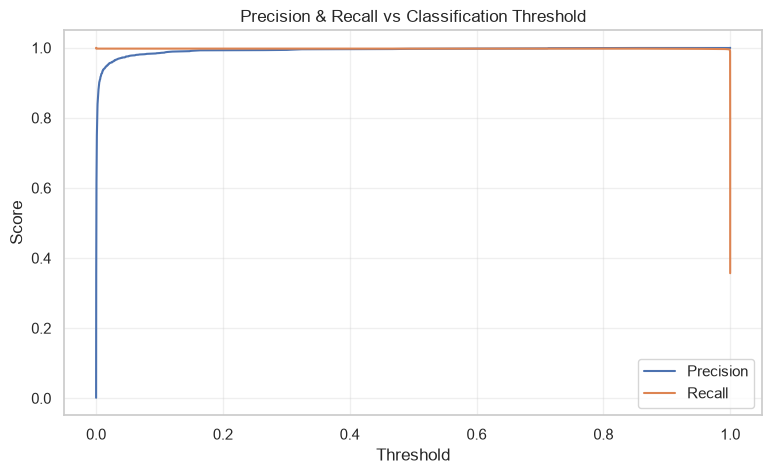

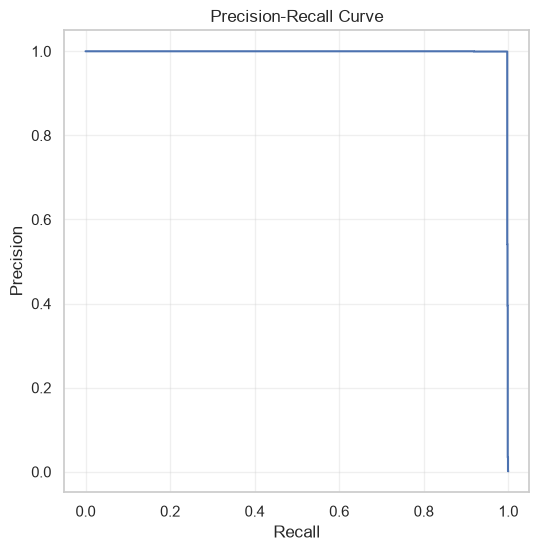

Best F1 threshold: 0.8571
  Precision at this threshold: 0.9994
  Recall at this threshold:    0.9976
  F1-score:                    0.9985

Threshold for >= 90% recall: 1.0000
  Precision at this threshold: 1.0000
  Recall at this threshold:    0.9191

--- Default threshold (threshold=0.5000) ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9976    0.9976    0.9976      1643

    accuracy                         1.0000   1272524
   macro avg     0.9988    0.9988    0.9988   1272524
weighted avg     1.0000    1.0000    1.0000   1272524

Confusion matrix:
 [[1270877       4]
 [      4    1639]]

--- F1-optimal threshold (threshold=0.8571) ---
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9994    0.9976    0.9985      1643

    accuracy                         1.0000   1272524
   macro avg     0.9997    0.9988    0.9992   127

In [38]:
"""
Step 2: Threshold Tuning
Instead of the default 0.5 cutoff, pick a classification threshold
based on the precision/recall trade-off that matters for your use case.

Run this AFTER wire_graph_features.py (uses the graph-aware XGBoost model,
but works the same way for any model with predict_proba).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_recall_curve, f1_score,
                              precision_score, recall_score,
                              confusion_matrix, classification_report)
import joblib

# ------------------------------------------------------------------
# 1. LOAD MODEL + TEST DATA
# ------------------------------------------------------------------
model = joblib.load("xgboost_with_graph_features_model.pkl")
X_test = pd.read_csv("X_test_with_graph.csv")
y_test = pd.read_csv("y_test_with_graph.csv").squeeze()

y_proba = model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------------
# 2. COMPUTE PRECISION-RECALL CURVE ACROSS ALL THRESHOLDS
# ------------------------------------------------------------------
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# precision_recall_curve returns one more precision/recall point than
# thresholds (the last point is threshold=1.0 implicitly), so trim to align
precisions_aligned = precisions[:-1]
recalls_aligned = recalls[:-1]

# ------------------------------------------------------------------
# 3. PLOT PRECISION & RECALL VS THRESHOLD
# ------------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions_aligned, label='Precision')
plt.plot(thresholds, recalls_aligned, label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------------
# 4. PLOT PRECISION VS RECALL DIRECTLY
# ------------------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------------
# 5. FIND THRESHOLD THAT MAXIMIZES F1-SCORE
# ------------------------------------------------------------------
f1_scores = 2 * (precisions_aligned * recalls_aligned) / \
            (precisions_aligned + recalls_aligned + 1e-10)
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx]

print(f"Best F1 threshold: {best_f1_threshold:.4f}")
print(f"  Precision at this threshold: {precisions_aligned[best_f1_idx]:.4f}")
print(f"  Recall at this threshold:    {recalls_aligned[best_f1_idx]:.4f}")
print(f"  F1-score:                    {f1_scores[best_f1_idx]:.4f}")

# ------------------------------------------------------------------
# 6. FIND THRESHOLD FOR A TARGET RECALL (fraud-detection priority)
# ------------------------------------------------------------------
# In fraud detection, missing fraud (false negative) is usually costlier
# than a false alarm (false positive) — so many teams target a MINIMUM
# recall level and accept the precision that comes with it.
TARGET_RECALL = 0.90  # <-- adjust based on business risk tolerance

valid_idx = np.where(recalls_aligned >= TARGET_RECALL)[0]
if len(valid_idx) > 0:
    # Among thresholds hitting the target recall, pick the one with
    # highest precision (least false alarms)
    best_idx = valid_idx[np.argmax(precisions_aligned[valid_idx])]
    recall_threshold = thresholds[best_idx]
    print(f"\nThreshold for >= {TARGET_RECALL:.0%} recall: {recall_threshold:.4f}")
    print(f"  Precision at this threshold: {precisions_aligned[best_idx]:.4f}")
    print(f"  Recall at this threshold:    {recalls_aligned[best_idx]:.4f}")
else:
    print(f"\nNo threshold achieves >= {TARGET_RECALL:.0%} recall — "
          f"model may need improvement, or lower the target.")
    recall_threshold = best_f1_threshold  # fallback

# ------------------------------------------------------------------
# 7. COMPARE: DEFAULT (0.5) VS F1-OPTIMAL VS RECALL-TARGETED
# ------------------------------------------------------------------
def evaluate_threshold(threshold, label):
    y_pred = (y_proba >= threshold).astype(int)
    print(f"\n--- {label} (threshold={threshold:.4f}) ---")
    print(classification_report(y_test, y_pred, digits=4))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

evaluate_threshold(0.5, "Default threshold")
evaluate_threshold(best_f1_threshold, "F1-optimal threshold")
evaluate_threshold(recall_threshold, f"Recall-targeted (>={TARGET_RECALL:.0%}) threshold")

# ------------------------------------------------------------------
# 8. SAVE THE CHOSEN THRESHOLD FOR DEPLOYMENT
# ------------------------------------------------------------------
# Pick whichever threshold fits your business need — this example
# saves the recall-targeted one since fraud detection usually
# prioritizes catching fraud over minimizing false alarms.
CHOSEN_THRESHOLD = recall_threshold

import json
with open("chosen_threshold.json", "w") as f:
    json.dump({"threshold": float(CHOSEN_THRESHOLD)}, f)

print(f"\nSaved chosen threshold ({CHOSEN_THRESHOLD:.4f}) to chosen_threshold.json")
print("Use this threshold at inference time instead of the default 0.5:")
print("  y_pred = (model.predict_proba(X_new)[:, 1] >= CHOSEN_THRESHOLD).astype(int)")

***Model Comparison.***

In [39]:
"""
Step 3: Model Comparison Summary
Compare all trained models side-by-side on PR-AUC, ROC-AUC, precision,
recall, and F1 — using each model's own appropriate test set.

Run this AFTER model_training.py, extended_modeling_all_approaches.py,
and wire_graph_features.py have all been run (so their .pkl files exist).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              average_precision_score, roc_auc_score)
import joblib
import json

results = []

def evaluate_model(name, model, X_test, y_test, threshold=0.5, is_iso_forest=False):
    if is_iso_forest:
        # Isolation Forest doesn't use predict_proba the same way —
        # decision_function: lower score = more anomalous
        raw_pred = model.predict(X_test)
        y_pred = np.where(raw_pred == -1, 1, 0)
        # Use negative decision_function as a pseudo-probability for PR-AUC
        y_score = -model.decision_function(X_test)
    else:
        y_score = model.predict_proba(X_test)[:, 1]
        y_pred = (y_score >= threshold).astype(int)

    results.append({
        "Model": name,
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "PR-AUC": average_precision_score(y_test, y_score),
        "ROC-AUC": roc_auc_score(y_test, y_score),
    })

In [40]:
# ------------------------------------------------------------------
# 1. LOAD STANDARD TEST SET (used by Logistic Regression, Random Forest,
#    XGBoost, LightGBM, Isolation Forest — all trained WITHOUT graph feats)
# ------------------------------------------------------------------
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv").squeeze()

log_reg = joblib.load("logistic_regression_model.pkl")
rf = joblib.load("random_forest_model.pkl")
xgb_model = joblib.load("xgboost_model.pkl")
lgb_model = joblib.load("lightgbm_model.pkl")
iso_forest = joblib.load("isolation_forest_model.pkl")

evaluate_model("Logistic Regression", log_reg, X_test, y_test)
evaluate_model("Random Forest (SMOTE)", rf, X_test, y_test)
evaluate_model("XGBoost", xgb_model, X_test, y_test)
evaluate_model("LightGBM", lgb_model, X_test, y_test)
evaluate_model("Isolation Forest (unsupervised)", iso_forest, X_test, y_test,
               is_iso_forest=True)

# ------------------------------------------------------------------
# 2. LOAD GRAPH-AWARE TEST SET (different feature columns, so separate)
# ------------------------------------------------------------------
X_test_graph = pd.read_csv("X_test_with_graph.csv")
y_test_graph = pd.read_csv("y_test_with_graph.csv").squeeze()

xgb_graph = joblib.load("xgboost_with_graph_features_model.pkl")
lgb_graph = joblib.load("lightgbm_with_graph_features_model.pkl")

evaluate_model("XGBoost + Graph Features", xgb_graph, X_test_graph, y_test_graph)
evaluate_model("LightGBM + Graph Features", lgb_graph, X_test_graph, y_test_graph)

# ------------------------------------------------------------------
# 3. ADD TUNED-THRESHOLD VERSION OF BEST GRAPH MODEL (if available)
# ------------------------------------------------------------------
try:
    with open("chosen_threshold.json") as f:
        chosen_threshold = json.load(f)["threshold"]
    evaluate_model("XGBoost + Graph Features (tuned threshold)",
                    xgb_graph, X_test_graph, y_test_graph,
                    threshold=chosen_threshold)
except FileNotFoundError:
    print("chosen_threshold.json not found — skipping tuned-threshold row "
          "(run threshold_tuning.py first).")

# ------------------------------------------------------------------
# 4. BUILD COMPARISON TABLE
# ------------------------------------------------------------------
results_df = pd.DataFrame(results).sort_values("PR-AUC", ascending=False)
results_df = results_df.round(4)

print("\n=== MODEL COMPARISON (sorted by PR-AUC) ===\n")
print(results_df.to_string(index=False))

results_df.to_csv("model_comparison_summary.csv", index=False)
print("\nSaved: model_comparison_summary.csv")


=== MODEL COMPARISON (sorted by PR-AUC) ===

                                     Model  Threshold  Precision  Recall     F1  PR-AUC  ROC-AUC
                     Random Forest (SMOTE)        0.5     0.9687  0.9982 0.9832  0.9987   0.9997
                                   XGBoost        0.5     0.9957  0.9976 0.9967  0.9983   0.9995
                  XGBoost + Graph Features        0.5     0.9976  0.9976 0.9976  0.9981   0.9995
XGBoost + Graph Features (tuned threshold)        1.0     1.0000  0.9191 0.9578  0.9981   0.9995
                       Logistic Regression        0.5     0.0273  0.9428 0.0531  0.5798   0.9894
                                  LightGBM        0.5     0.0163  0.9038 0.0321  0.0149   0.9167
           Isolation Forest (unsupervised)        0.5     0.0144  0.0140 0.0142  0.0121   0.8135
                 LightGBM + Graph Features        0.5     0.0045  0.8010 0.0090  0.0039   0.7870

Saved: model_comparison_summary.csv


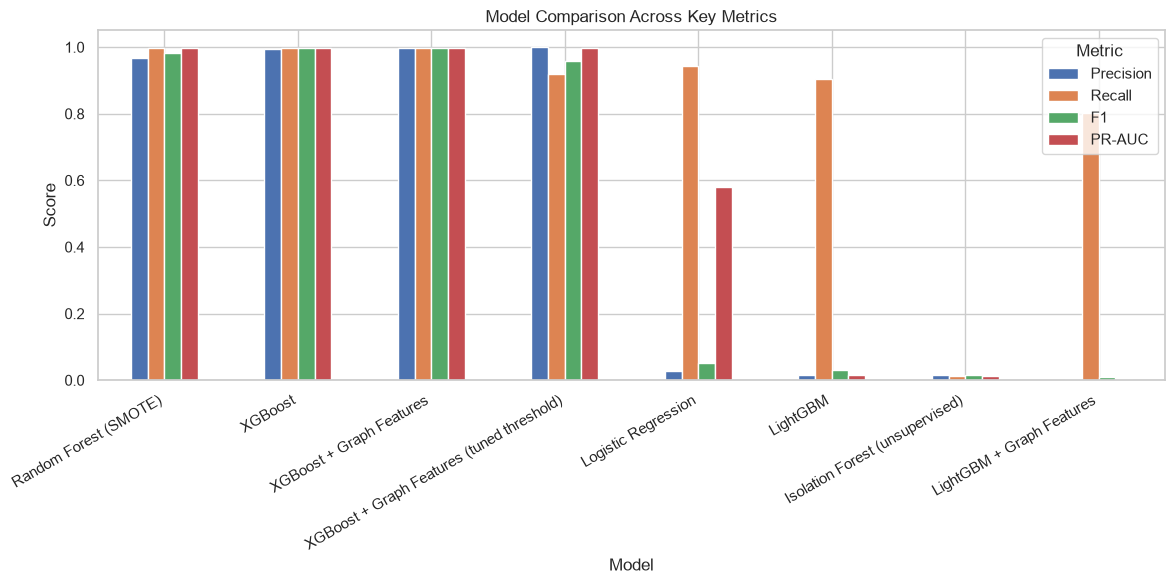

In [41]:
# ------------------------------------------------------------------
# 5. VISUALIZE COMPARISON
# ------------------------------------------------------------------
metrics_to_plot = ["Precision", "Recall", "F1", "PR-AUC"]
plot_df = results_df.set_index("Model")[metrics_to_plot]

plot_df.plot(kind='bar', figsize=(12, 6))
plt.title("Model Comparison Across Key Metrics")
plt.ylabel("Score")
plt.xticks(rotation=30, ha='right')
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [42]:
# ------------------------------------------------------------------
# 6. HIGHLIGHT THE WINNER
# ------------------------------------------------------------------
best_model_row = results_df.iloc[0]
print(f"\nBest model by PR-AUC: {best_model_row['Model']} "
      f"(PR-AUC={best_model_row['PR-AUC']:.4f}, "
      f"Recall={best_model_row['Recall']:.4f}, "
      f"Precision={best_model_row['Precision']:.4f})")
print("\nNote: 'best' depends on your priorities. If catching more fraud")
print("matters more than false alarms, weigh Recall heavier than PR-AUC")
print("alone when making the final choice.")


Best model by PR-AUC: Random Forest (SMOTE) (PR-AUC=0.9987, Recall=0.9982, Precision=0.9687)

Note: 'best' depends on your priorities. If catching more fraud
matters more than false alarms, weigh Recall heavier than PR-AUC
alone when making the final choice.


***Deployment Stage.***

In [43]:
"""
Step 4: Final Model Selection & Packaging for Deployment
Bundles the chosen model + its preprocessing logic + tuned threshold
into a single reusable artifact, plus a predict() function to score
new, raw transactions exactly like the ones that arrive in production.

Run this AFTER model_comparison.py has identified the best model.
"""

import pandas as pd
import numpy as np
import joblib
import json

# ------------------------------------------------------------------
# 1. CHOOSE THE FINAL MODEL
# ------------------------------------------------------------------
# Update these two lines based on what model_comparison.py showed as best.
# Example assumes "XGBoost + Graph Features (tuned threshold)" won.
FINAL_MODEL_PATH = "xgboost_with_graph_features_model.pkl"
FINAL_MODEL_NAME = "XGBoost + Graph Features"

model = joblib.load(FINAL_MODEL_PATH)

with open("chosen_threshold.json") as f:
    threshold = json.load(f)["threshold"]

# The exact column order/set the model was trained on — critical to
# preserve, since tree models expect features in a consistent shape.
X_test_graph = pd.read_csv("X_test_with_graph.csv")
FEATURE_COLUMNS = X_test_graph.columns.tolist()

print(f"Packaging model: {FINAL_MODEL_NAME}")
print(f"Threshold: {threshold:.4f}")
print(f"Expected feature columns ({len(FEATURE_COLUMNS)}):\n{FEATURE_COLUMNS}")

Packaging model: XGBoost + Graph Features
Threshold: 1.0000
Expected feature columns (18):
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'origBalanceZero', 'destBalanceZero', 'origIsMerchant', 'destIsMerchant', 'dest_in_degree', 'orig_out_degree', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [44]:
# ------------------------------------------------------------------
# 2. PREPROCESSING FUNCTION — mirrors cleaning + feature engineering
#    steps exactly, so a NEW raw transaction can be scored the same way
#    training data was prepared.
# ------------------------------------------------------------------
def preprocess_transaction(raw_df, graph_degree_lookup=None):
    """
    raw_df: DataFrame with raw columns matching the original schema:
        step, type, amount, nameOrig, oldbalanceOrg, newbalanceOrig,
        nameDest, oldbalanceDest, newbalanceDest
        (isFraud / isFlaggedFraud not required for inference)

    graph_degree_lookup: optional dict with 'in_degree' and 'out_degree'
        dicts (precomputed from historical data) to map nameDest/nameOrig
        to their network degree. If None, degrees default to 0
        (safe fallback for brand-new accounts not seen in training graph).
    """
    df = raw_df.copy()

    # --- basic type safety (mirrors clean_fraud_data.py) ---
    df['type'] = df['type'].astype(str)
    df['nameOrig'] = df['nameOrig'].astype(str)
    df['nameDest'] = df['nameDest'].astype(str)
    for col in ['amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # --- engineered features (mirrors clean_fraud_data.py) ---
    df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
    df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
    df['origBalanceZero'] = ((df['oldbalanceOrg'] == 0) &
                              (df['newbalanceOrig'] == 0)).astype(int)
    df['destBalanceZero'] = ((df['oldbalanceDest'] == 0) &
                              (df['newbalanceDest'] == 0)).astype(int)
    df['origIsMerchant'] = df['nameOrig'].str.startswith('M').astype(int)
    df['destIsMerchant'] = df['nameDest'].str.startswith('M').astype(int)

    # --- graph features (mirrors extended_modeling_all_approaches.py) ---
    if graph_degree_lookup is not None:
        df['dest_in_degree'] = df['nameDest'].map(
            graph_degree_lookup.get('in_degree', {})).fillna(0)
        df['orig_out_degree'] = df['nameOrig'].map(
            graph_degree_lookup.get('out_degree', {})).fillna(0)
    else:
        df['dest_in_degree'] = 0
        df['orig_out_degree'] = 0

    # --- one-hot encode type, aligned to training columns ---
    df = pd.get_dummies(df, columns=['type'], prefix='type', drop_first=True)

    # --- drop non-feature columns if present ---
    drop_cols = [c for c in ['nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud']
                 if c in df.columns]
    df = df.drop(columns=drop_cols)

    # --- align to the exact training feature set/order ---
    # any dummy column missing in new data (e.g. a type not present in this
    # batch) is added as all-zero; any unexpected column is dropped.
    df = df.reindex(columns=FEATURE_COLUMNS, fill_value=0)

    return df


# ------------------------------------------------------------------
# 3. INFERENCE FUNCTION
# ------------------------------------------------------------------
def predict_fraud(raw_df, graph_degree_lookup=None):
    """
    Takes raw transaction(s) and returns fraud probability + flag
    using the packaged model and tuned threshold.
    """
    X_new = preprocess_transaction(raw_df, graph_degree_lookup)
    proba = model.predict_proba(X_new)[:, 1]
    flag = (proba >= threshold).astype(int)

    return pd.DataFrame({
        "fraud_probability": proba,
        "is_flagged_fraud": flag
    })


# ------------------------------------------------------------------
# 4. SAVE COMPLETE DEPLOYMENT BUNDLE
# ------------------------------------------------------------------
deployment_bundle = {
    "model": model,
    "threshold": threshold,
    "feature_columns": FEATURE_COLUMNS,
    "model_name": FINAL_MODEL_NAME,
}
joblib.dump(deployment_bundle, "fraud_detection_deployment_bundle.pkl")
print("\nSaved: fraud_detection_deployment_bundle.pkl")
print("This single file contains everything needed to score new transactions.")

# ------------------------------------------------------------------
# 5. QUICK TEST — SCORE A SAMPLE TRANSACTION
# ------------------------------------------------------------------
sample_transaction = pd.DataFrame([{
    "step": 1,
    "type": "TRANSFER",
    "amount": 181.0,
    "nameOrig": "C1231006815",
    "oldbalanceOrg": 181.0,
    "newbalanceOrig": 0.0,
    "nameDest": "C1666544295",
    "oldbalanceDest": 0.0,
    "newbalanceDest": 0.0,
}])

result = predict_fraud(sample_transaction)
print("\nSample transaction scoring result:")
print(result)

# ------------------------------------------------------------------
# 6. HOW TO LOAD AND USE THIS BUNDLE ELSEWHERE (e.g. a scoring service)
# ------------------------------------------------------------------
print("""
--- Usage in a separate script/service ---
import joblib
bundle = joblib.load("fraud_detection_deployment_bundle.pkl")
model = bundle["model"]
threshold = bundle["threshold"]
feature_columns = bundle["feature_columns"]
# Re-run preprocess_transaction() logic (copy the function) before
# calling model.predict_proba() on the aligned features.
""")


Saved: fraud_detection_deployment_bundle.pkl
This single file contains everything needed to score new transactions.

Sample transaction scoring result:
   fraud_probability  is_flagged_fraud
0           0.999897                 0

--- Usage in a separate script/service ---
import joblib
bundle = joblib.load("fraud_detection_deployment_bundle.pkl")
model = bundle["model"]
threshold = bundle["threshold"]
feature_columns = bundle["feature_columns"]
# Re-run preprocess_transaction() logic (copy the function) before
# calling model.predict_proba() on the aligned features.



***Fix Logistic Regression Calibration.***

In [47]:
"""
Fix Logistic Regression Calibration + Package as Final Deployed Model

The original class_weight='balanced' was too aggressive, pushing precision
down to ~0.03 (97%+ false alarm rate). This script:
  1. Retrains Logistic Regression with more moderate class weighting
  2. Tunes the threshold specifically for this model
  3. Packages it as the final deployment bundle

Run this AFTER feature_engineering_split.py (uses X_train.csv etc.)
"""

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_curve, average_precision_score,
                              roc_auc_score, f1_score)
import joblib
import json

# ------------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------------
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

FEATURE_COLUMNS = X_train.columns.tolist()

# ------------------------------------------------------------------
# 2. SCALE FEATURES
# ------------------------------------------------------------------
# Logistic Regression is sensitive to feature scale (unlike tree models).
# amount/balance columns are on a very different scale than the 0/1 flag
# columns, which distorts the learned coefficients and contributes to
# poor calibration. This step alone often meaningfully improves precision.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------------
# 3. RETRAIN WITH MODERATE CLASS WEIGHTING (instead of 'balanced')
# ------------------------------------------------------------------
# 'balanced' sets weight inversely proportional to class frequency, which
# for ~0.1%-1% fraud rates can mean weighting fraud cases 100-1000x more
# than legitimate ones -- too extreme, causing the model to over-flag.
# A fixed, moderate weight avoids that overcorrection.
log_reg = LogisticRegression(
    class_weight={0: 1, 1: 10},   # moderate weighting instead of 'balanced'
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)

print("=== Logistic Regression (recalibrated, threshold=0.5) ===")
print(classification_report(y_test, y_pred_default, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_default))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

# ------------------------------------------------------------------
# 4. TUNE THRESHOLD SPECIFICALLY FOR THIS MODEL
# ------------------------------------------------------------------
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
precisions_aligned = precisions[:-1]
recalls_aligned = recalls[:-1]

f1_scores = 2 * (precisions_aligned * recalls_aligned) / \
            (precisions_aligned + recalls_aligned + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nBest F1 threshold: {best_threshold:.4f}")
print(f"  Precision: {precisions_aligned[best_idx]:.4f}")
print(f"  Recall:    {recalls_aligned[best_idx]:.4f}")
print(f"  F1:        {f1_scores[best_idx]:.4f}")

y_pred_tuned = (y_proba >= best_threshold).astype(int)
print(f"\n=== Logistic Regression (recalibrated, tuned threshold={best_threshold:.4f}) ===")
print(classification_report(y_test, y_pred_tuned, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_tuned))

# ------------------------------------------------------------------
# 5. PACKAGE AS FINAL DEPLOYMENT BUNDLE
# ------------------------------------------------------------------
# NOTE: scaler must be included in the bundle -- new data must be scaled
# with the SAME fitted scaler before prediction, or results will be wrong.
deployment_bundle = {
    "model": log_reg,
    "scaler": scaler,
    "threshold": float(best_threshold),
    "feature_columns": FEATURE_COLUMNS,
    "model_name": "Logistic Regression (recalibrated)",
}
joblib.dump(deployment_bundle, "fraud_detection_deployment_bundle.pkl")
print("\nSaved: fraud_detection_deployment_bundle.pkl")

# ------------------------------------------------------------------
# 6. INFERENCE FUNCTION (mirrors final_model_packaging.py logic,
#    with the added scaling step this model requires)
# ------------------------------------------------------------------
def preprocess_transaction(raw_df):
    df = raw_df.copy()
    df['type'] = df['type'].astype(str)
    df['nameOrig'] = df['nameOrig'].astype(str)
    df['nameDest'] = df['nameDest'].astype(str)
    for col in ['amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
    df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
    df['origBalanceZero'] = ((df['oldbalanceOrg'] == 0) &
                              (df['newbalanceOrig'] == 0)).astype(int)
    df['destBalanceZero'] = ((df['oldbalanceDest'] == 0) &
                              (df['newbalanceDest'] == 0)).astype(int)
    df['origIsMerchant'] = df['nameOrig'].str.startswith('M').astype(int)
    df['destIsMerchant'] = df['nameDest'].str.startswith('M').astype(int)

    df = pd.get_dummies(df, columns=['type'], prefix='type', drop_first=True)
    drop_cols = [c for c in ['nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud']
                 if c in df.columns]
    df = df.drop(columns=drop_cols)
    df = df.reindex(columns=FEATURE_COLUMNS, fill_value=0)
    return df


def predict_fraud(raw_df):
    X_new = preprocess_transaction(raw_df)
    X_new_scaled = scaler.transform(X_new)   # <-- critical: must scale first
    proba = log_reg.predict_proba(X_new_scaled)[:, 1]
    flag = (proba >= best_threshold).astype(int)
    return pd.DataFrame({"fraud_probability": proba, "is_flagged_fraud": flag})

=== Logistic Regression (recalibrated, threshold=0.5) ===
              precision    recall  f1-score   support

           0     0.9997    0.9995    0.9996   1270881
           1     0.6524    0.7529    0.6991      1643

    accuracy                         0.9992   1272524
   macro avg     0.8261    0.8762    0.8493   1272524
weighted avg     0.9992    0.9992    0.9992   1272524

Confusion matrix:
 [[1270222     659]
 [    406    1237]]
ROC-AUC: 0.9927549963910646
PR-AUC: 0.7613039697222795

Best F1 threshold: 0.9022
  Precision: 0.8922
  Recall:    0.6446
  F1:        0.7484

=== Logistic Regression (recalibrated, tuned threshold=0.9022) ===
              precision    recall  f1-score   support

           0     0.9995    0.9999    0.9997   1270881
           1     0.8922    0.6446    0.7484      1643

    accuracy                         0.9994   1272524
   macro avg     0.9459    0.8222    0.8741   1272524
weighted avg     0.9994    0.9994    0.9994   1272524

Confusion matrix:
 [

***QUICK TEST.***

In [46]:
sample_transaction = pd.DataFrame([{
    "step": 2, "type": "Payment", "amount": 130.0,
    "nameOrig": "C293339784", "oldbalanceOrg": 100.0, "newbalanceOrig": 0.0,
    "nameDest": "C474674449", "oldbalanceDest": 0.0, "newbalanceDest": 0.0,
}])
print("\nSample transaction scoring result:")
print(predict_fraud(sample_transaction))


Sample transaction scoring result:
   fraud_probability  is_flagged_fraud
0           0.000074                 0
